# Predicción del coste del seguro médico de una persona 

In [83]:
import json
import pandas as pd

url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"

total_data = pd.read_csv(url)

total_data.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Step 2: Exploración y limpieza de datos

In [84]:
# Obtener las dimensiones
total_data.shape

(1338, 7)

In [85]:
# Obtener información de las columnas con valores nulos
total_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

El dataset está completo, sin huecos que rellenar.

## PASO 3: Análisis de variables univariante

In [86]:
fig, axis = plt.subplots(2, 4, figsize=(16, 8))

variables = ["age", "sex", "bmi", "children", "smoker", "region", "charges"]

# Dibujar cada histograma en su subplot
for i, var in enumerate(variables):
    fila = i // 4
    col = i % 4
    sns.histplot(ax = axis[fila, col], data = total_data, x = var)
    axis[fila, col].set_title(var)

# Ocultar el subplot vacío (el 8º)
axis[1,3].axis("off")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

De las variables que encontramos:
Age = Edad del beneficiario principal (numérico)
Sex = Género del beneficiario principal (categórico)
BMI = índice de masa corporal (numérico)
Children = Número de niños/dependientes cubiertos por un seguro médico (numérico)
Smoker = ¿Es fumador? (categórico)
Region = Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)
Charges = Prima del seguro médico (numérico)

Análisis de variables numéricas

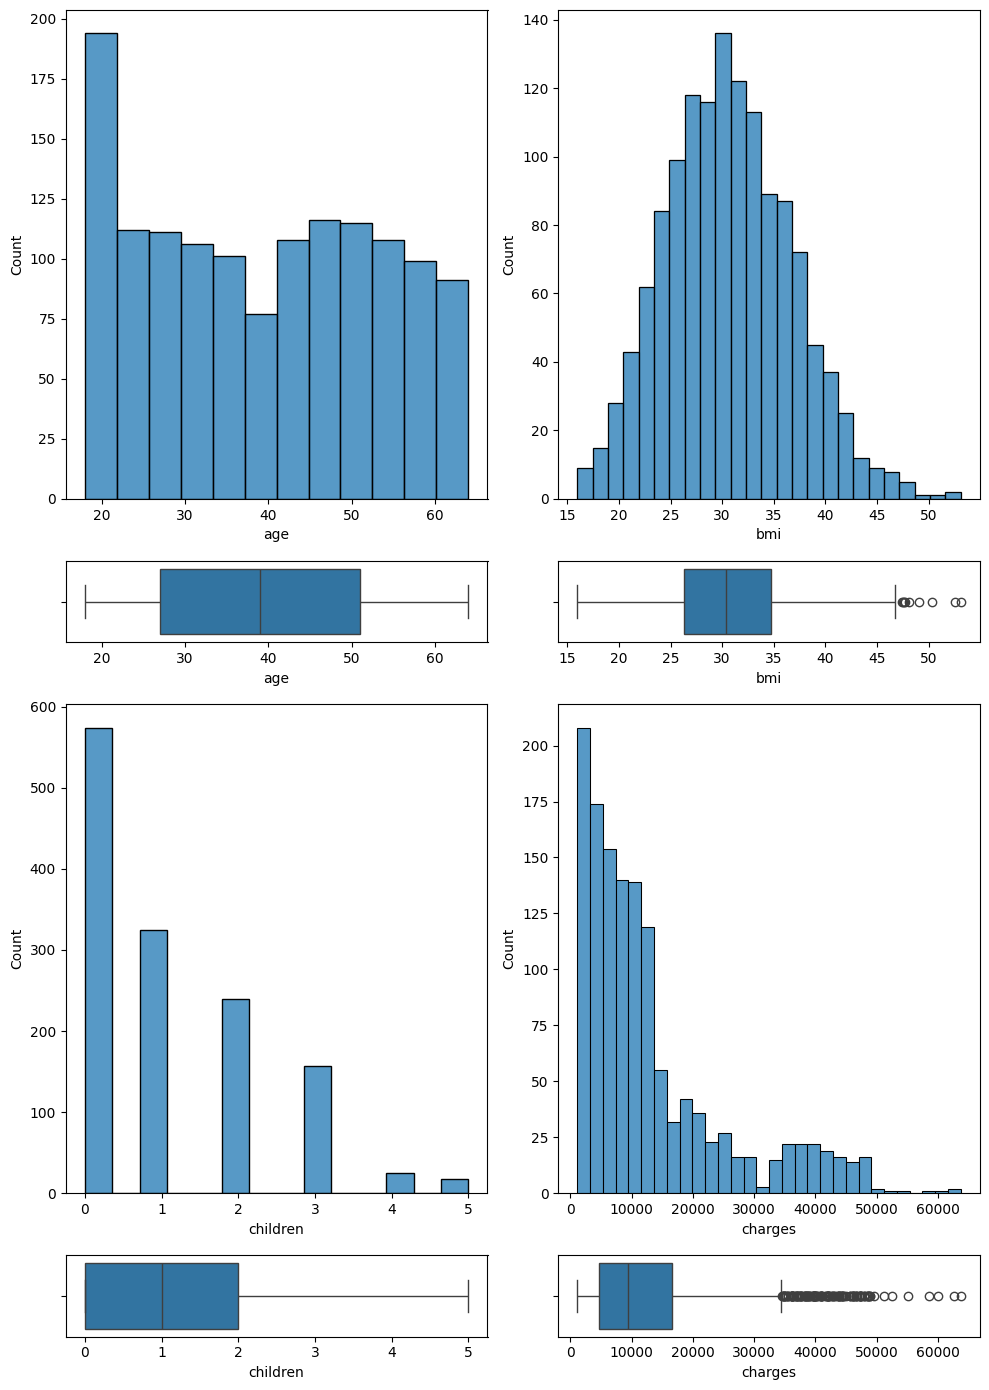

In [ ]:
fig, axis = plt.subplots(4, 2, figsize = (10, 14), gridspec_kw = {"height_ratios": [6, 1, 6, 1]})

sns.histplot(ax = axis[0, 0], data = total_data, x = "age")
sns.boxplot(ax = axis[1, 0], data = total_data, x = "age")

sns.histplot(ax = axis[0, 1], data = total_data, x = "bmi")
sns.boxplot(ax = axis[1, 1], data = total_data, x = "bmi")

sns.histplot(ax = axis[2, 0], data = total_data, x = "children")
sns.boxplot(ax = axis[3, 0], data = total_data, x = "children")

sns.histplot(ax = axis[2,1], data = total_data, x = "charges")
sns.boxplot(ax = axis[3, 1], data = total_data, x = "charges")

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

Age :La población está bien distribuida, pero ligeramente inclinada hacia edades jóvenes. Esto puede influir en los costes, ya que personas jóvenes suelen tener menos gastos médicos.
BMI o Índice de Masa Corporal: La mayoría de personas tienen un BMI entre 25 y 35 (sobrepeso). Los valores altos pueden ser importantes porque el BMI suele correlacionar con mayores costes médicos.
Children: La distribución es muy sesgada a la izquierda por lo que en sy mayoría tiene 0 hijos, luego 1 o 2, y muy pocos tienen más de 3.
Charges: Los costes médicos no siguen una distribución normal. Hay muchos casos baratos y pocos casos extremadamente caros. Esto es típico en seguros médicos y sugiere transformaciones (como logaritmos) para modelos lineales.

# Paso 4: Análisis de Variable Multivariante

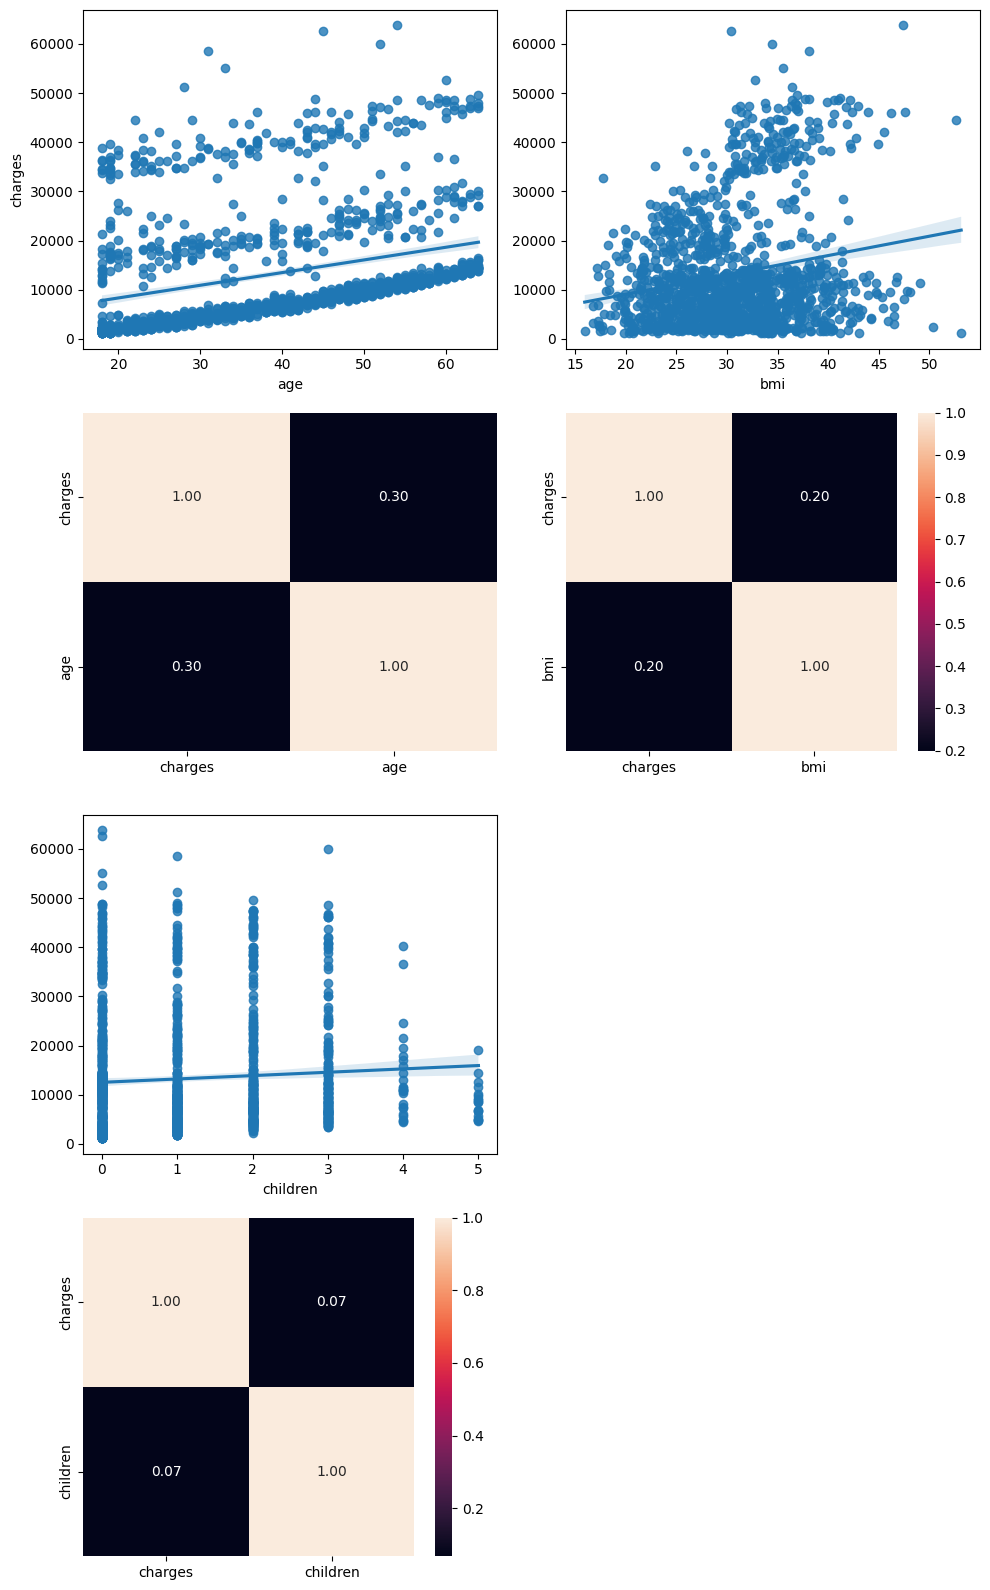

In [ ]:
# Numerical - Numerical Analysis

# Create subplot canvas
fig, axis = plt.subplots(4, 2, figsize = (10, 16))

# Create Plates
sns.regplot(ax = axis[0, 0], data = total_data, x = "age", y = "charges")
sns.heatmap(total_data[["charges", "age"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = total_data, x = "bmi", y = "charges").set(ylabel = None)
sns.heatmap(total_data[["charges", "bmi"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

sns.regplot(ax = axis[2, 0], data = total_data, x = "children", y = "charges").set(ylabel = None)
sns.heatmap(total_data[["charges", "children"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0]).set(ylabel = None)
fig.delaxes(axis[2, 1])
fig.delaxes(axis[3, 1])

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

Age	tiene una correlación de ~0.30 CON	Influencia moderada, útil para el modelo.

BMI	tiene una correlación de ~0.20	CON Influencia débil, aporta algo de información.

Children tiene una correlación de ~0.07	CON Influencia muy baja, casi irrelevante

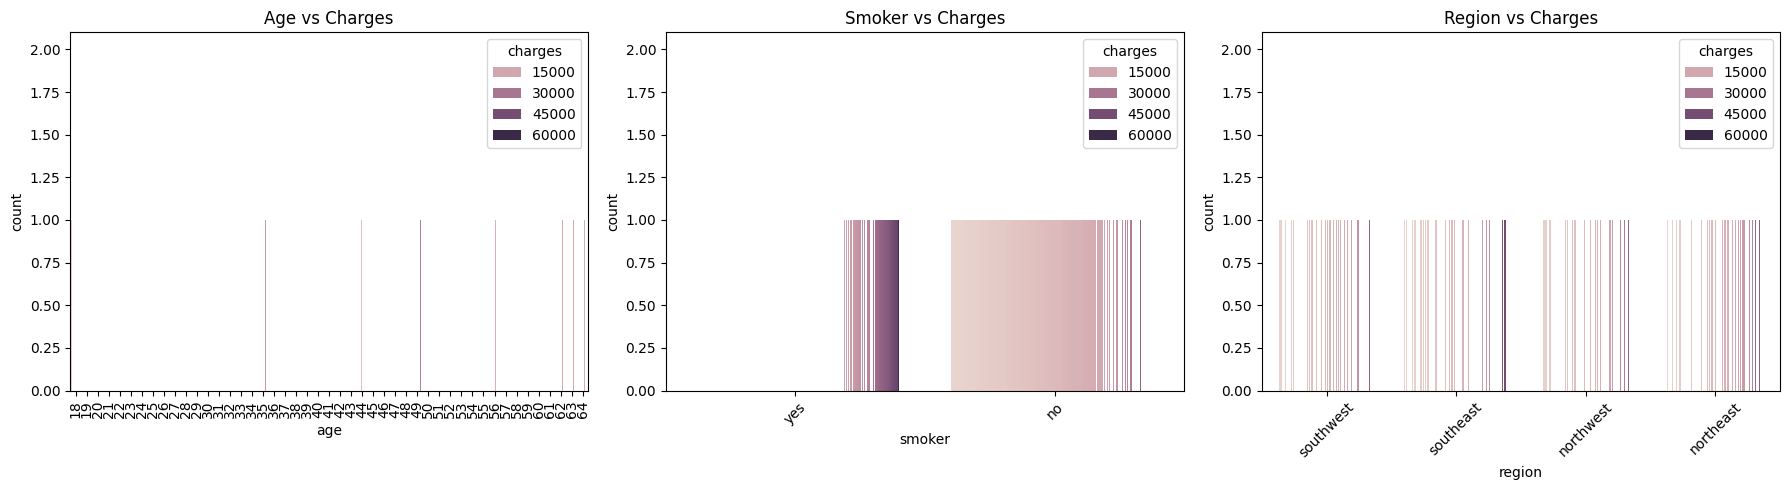

In [ ]:
# Crear figura y ejes (3 gráficos → 1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1
sns.countplot(
    ax=axes[0],
    data=total_data,
    x="age",
    hue="charges"
)
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_title("Age vs Charges")

# Gráfico 2
sns.countplot(
    ax=axes[1],
    data=total_data,
    x="smoker",
    hue="charges"
)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title("Smoker vs Charges")

# Gráfico 3
sns.countplot(
    ax=axes[2],
    data=total_data,
    x="region",
    hue="charges"
)
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title("Region vs Charges")

plt.tight_layout()
plt.show()


Smoker es la variable categórica más influyente del dataset.
Es un predictor extremadamente fuerte y separa claramente dos poblaciones distintas.

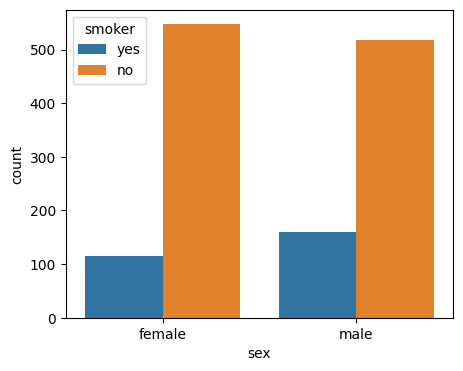

In [ ]:
##Análisis Categórico-Categórico

fig, axis = plt.subplots(figsize = (5, 4))

sns.countplot(data = total_data, x = "sex", hue = "smoker")

# Show the plot
plt.show()

Esto sugiere que sex y smoker son variables prácticamente independientes en este dataset.

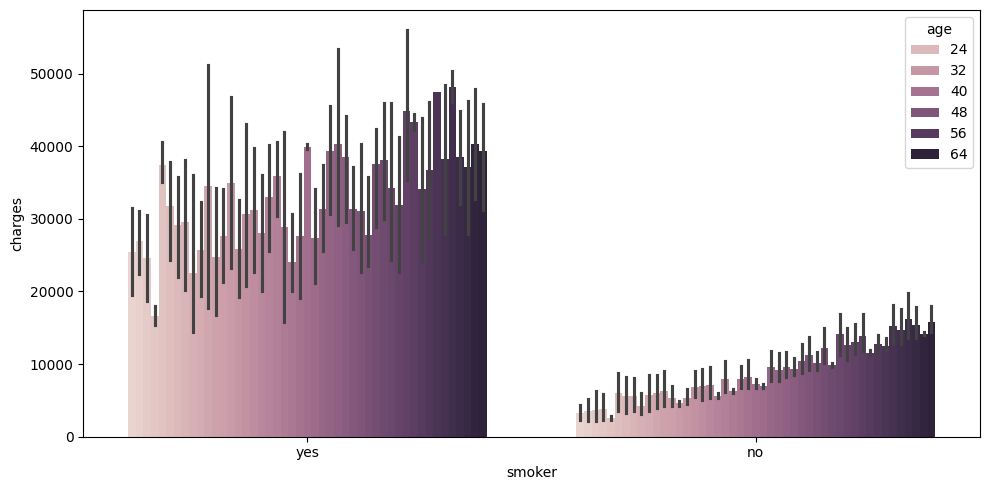

In [ ]:
## Combinaciones de grupos de barrios con varias predictoras: fumadores, edad y costes médicos
fig, axis = plt.subplots(figsize=(10, 5))

sns.barplot(ax=axis, data=total_data, x="smoker", y="charges", hue="age")

plt.tight_layout()
plt.show()

El diagrama muestra que los fumadores presentan costes médicos significativamente más altos que los no fumadores, y que la edad intensifica este efecto. Las personas mayores que fuman concentran los valores más elevados de charges, evidenciando una interacción clara entre edad y hábito de fumar.
Un fumador joven puede tener costes altos, pero no tanto como un fumador mayor.
Un no fumador mayor puede tener costes moderados, pero no tan altos como un fumador de la misma edad.

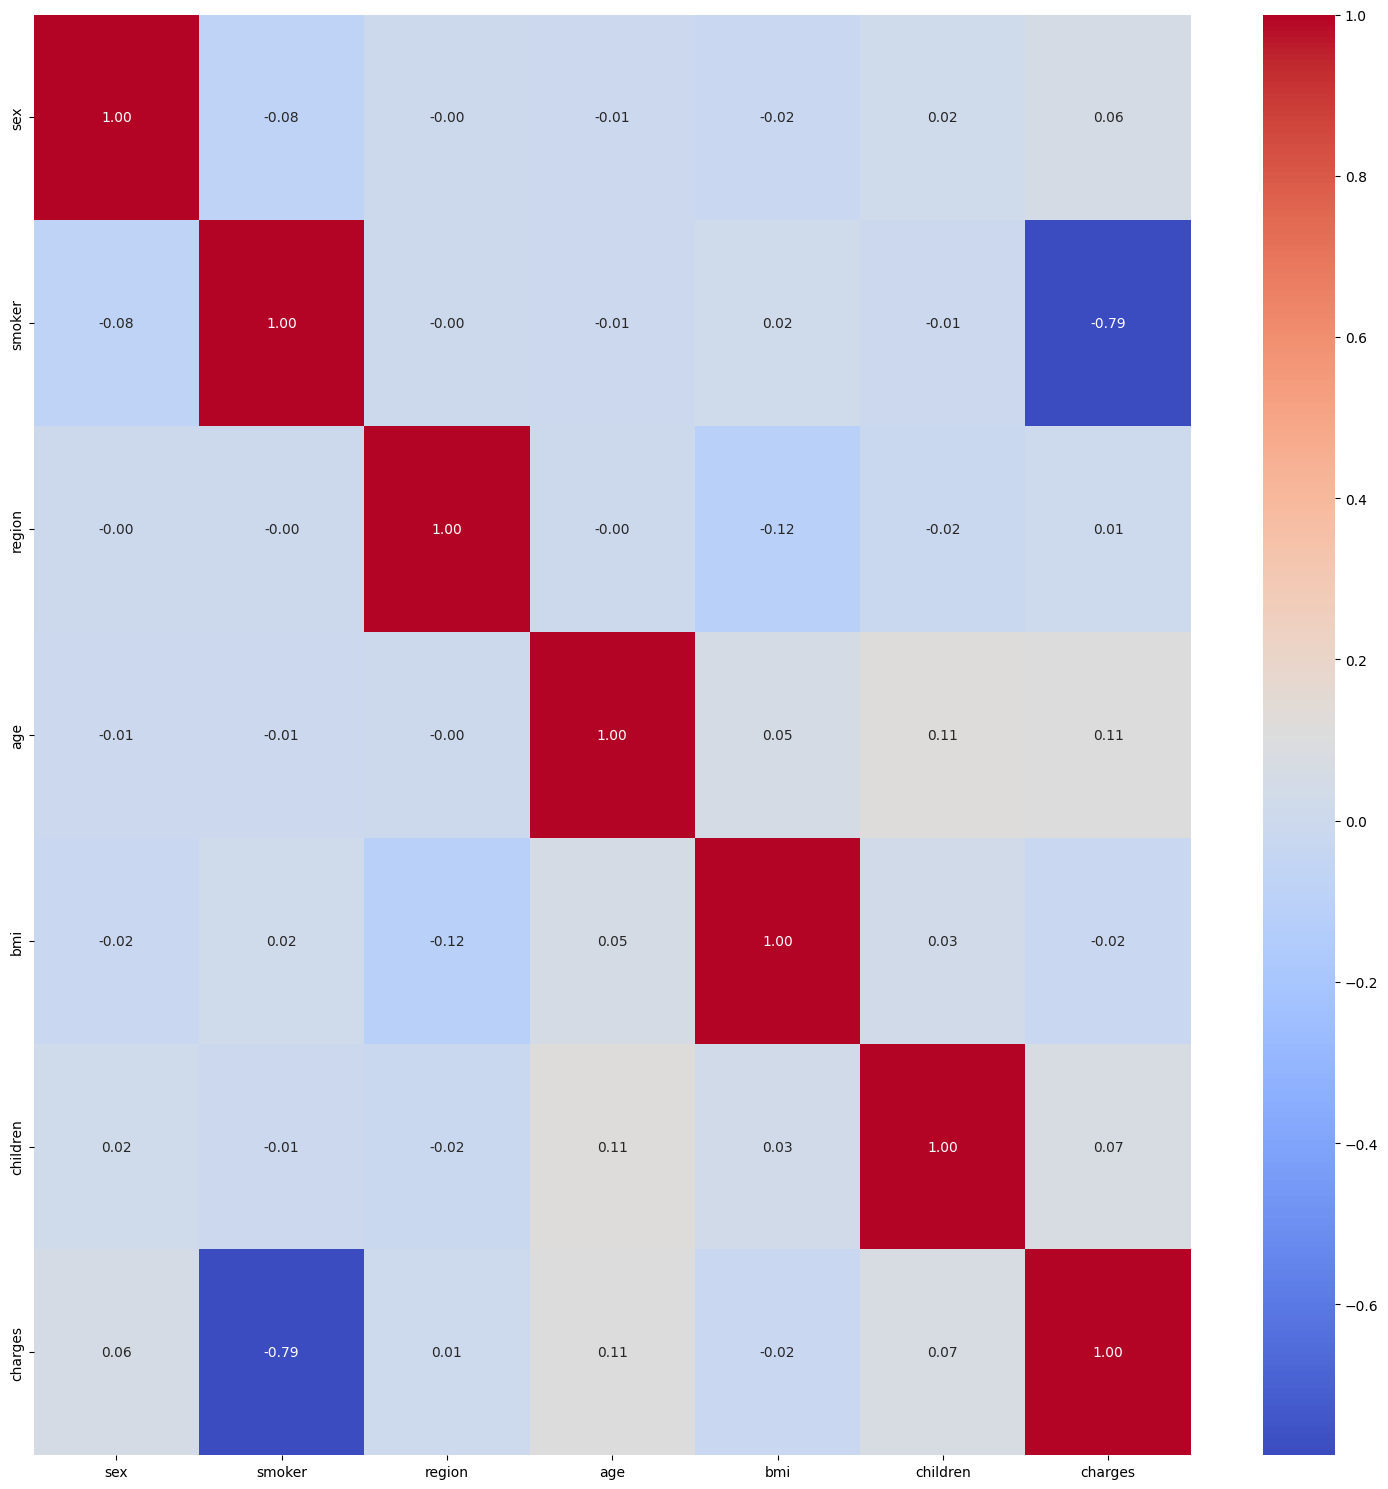

In [ ]:
df_corr = total_data.copy()

# Convertir variables categóricas a números
for col in ["sex", "smoker", "region"]:
    df_corr[col] = pd.factorize(df_corr[col])[0]

# Dibujar el plot
plt.figure(figsize=(15, 15))
sns.heatmap(
    df_corr[["sex", "smoker", "region",
             "age", "bmi", "children", "charges"]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm"
)
plt.tight_layout()
plt.show()


Smoker  TIENE UNA RELACIÓN	Muy fuerte (–0.79) = Fumar dispara los costes médicos.

Age     TIENE UNA RELACIÓN Débil (0.11) =	Los costes suben con la edad.

Children TIENE UNA RELACIÓN	Muy débil (0.07) = Poco impacto.

BMI      TIENE UNA RELACIÓN	Nula =	No influye en este dataset.

Sex      TIENE UNA RELACIÓN	Nula =	No hay diferencias entre hombres y mujeres.

Region   TIENE UNA RELACIÓN	Nula =	No hay diferencias entre regiones

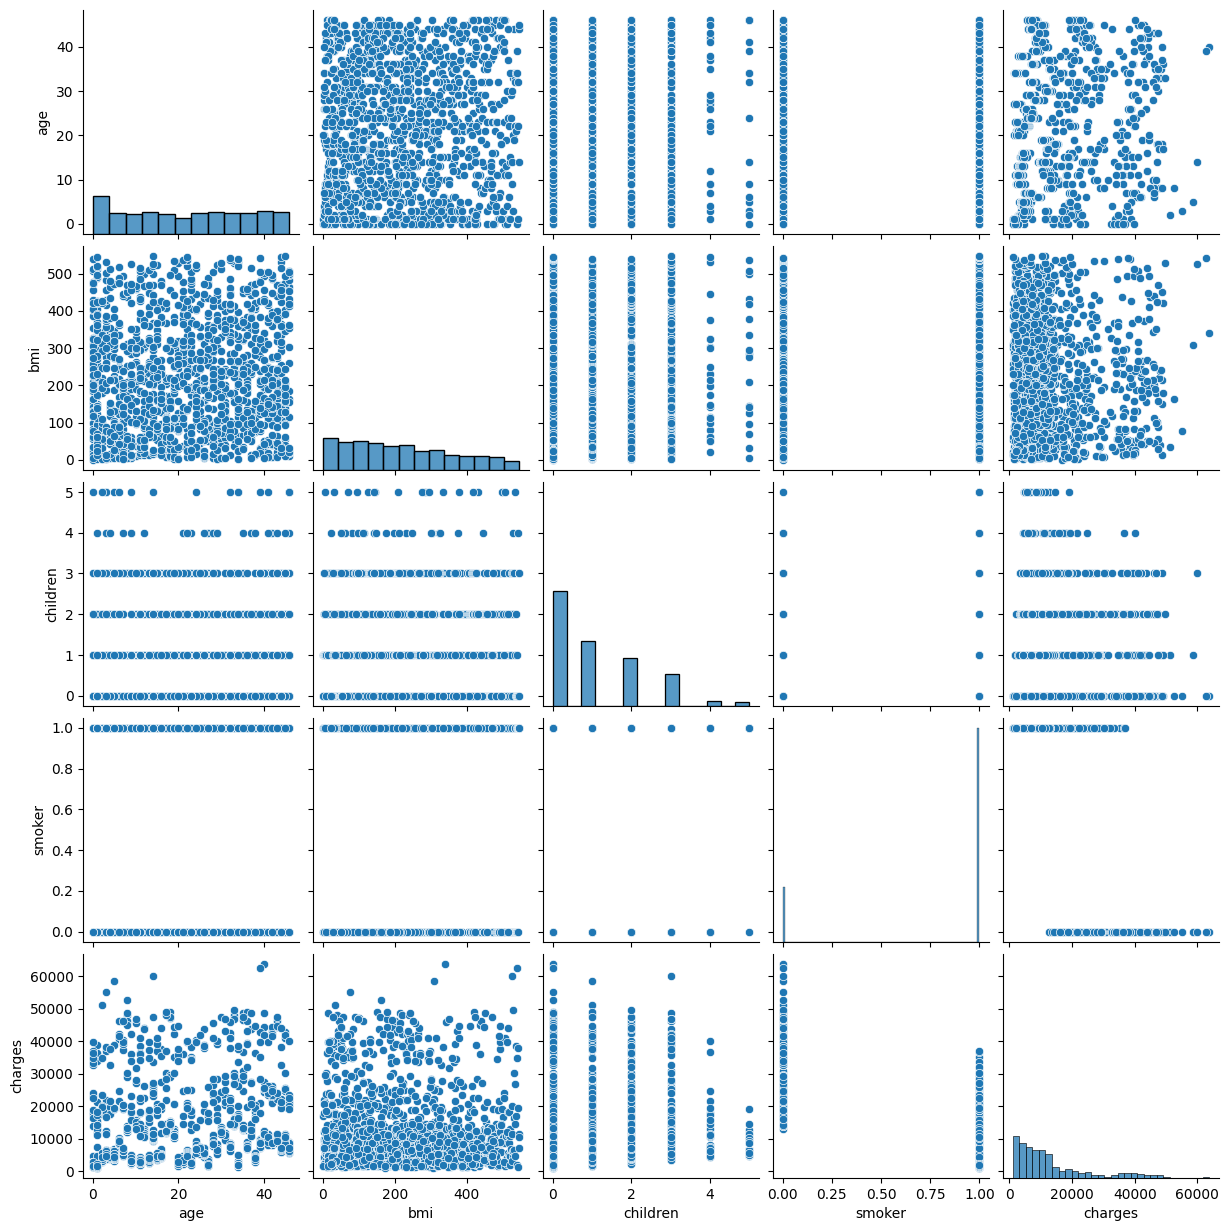

In [ ]:
##ANÁLISIS DE TODA LA DATA EN UNA SOLA##
sns.pairplot(data = total_data)

# PASO 5 : INGENIERÍA DE CARACTERÍSTICAS

In [ ]:
total_data.describe()

,age,bmi,children,smoker,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,21.736173,221.718236,1.094918,0.795217,13270.422265
std,14.298189,149.169320,1.205493,0.403694,12110.011237
min,0.000000,0.000000,0.000000,0.000000,1121.873900
25%,9.000000,95.250000,0.000000,1.000000,4740.287150
50%,22.000000,203.000000,1.000000,1.000000,9382.033000
75%,34.000000,333.000000,2.000000,1.000000,16639.912515
max,46.000000,547.000000,5.000000,1.000000,63770.428010


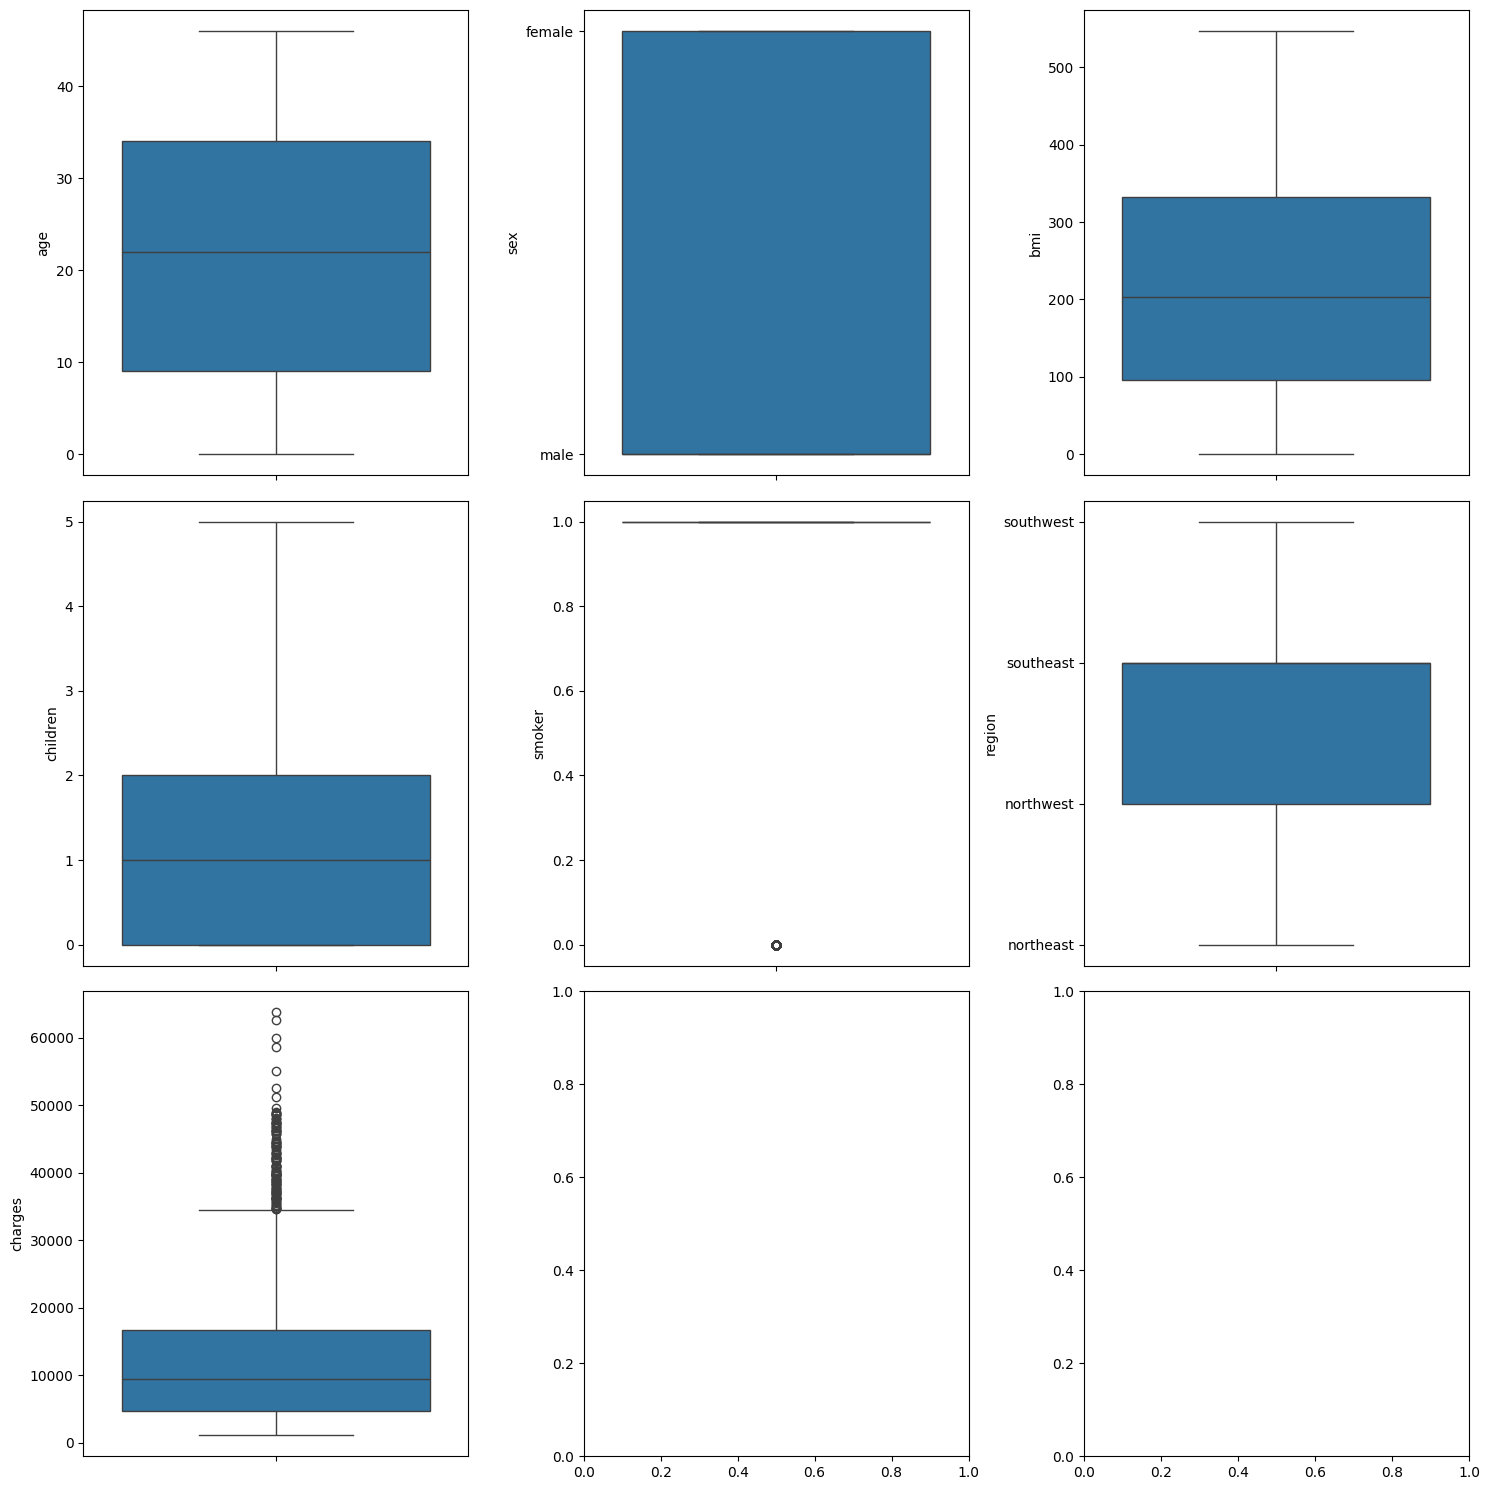

In [ ]:
fig, axes = plt.subplots(3, 3, figsize = (15, 15))

sns.boxplot(ax = axes[0, 0], data = total_data, y = "age")
sns.boxplot(ax = axes[0, 1], data = total_data, y = "sex")
sns.boxplot(ax = axes[0, 2], data = total_data, y = "bmi")
sns.boxplot(ax = axes[1, 0], data = total_data, y = "children")
sns.boxplot(ax = axes[1, 1], data = total_data, y = "smoker")
sns.boxplot(ax = axes[1, 2], data = total_data, y = "region")
sns.boxplot(ax = axes[2, 0], data = total_data, y = "charges")

plt.tight_layout()

plt.show()

In [ ]:
# Stats for charges
charges_stats = total_data["charges"].describe()
charges_stats

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

In [ ]:
# IQR para Charges

charges_iqr = charges_stats["75%"] - charges_stats["25%"]
upper_limit = charges_stats["75%"] + 1.5 * charges_iqr
lower_limit = charges_stats["25%"] - 1.5 * charges_iqr

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(charges_iqr, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 34489.35 y -13109.15, con un rango intercuartílico de 11899.63


In [ ]:
##Para la limpieza de outliers de Charges 
import numpy as np
total_data["log_charges"] = np.log(total_data["charges"])


Porque charges tiene una cola derecha muy larga (muchos valores altos), y la transformación logarítmica hace que la distribución sea más normal

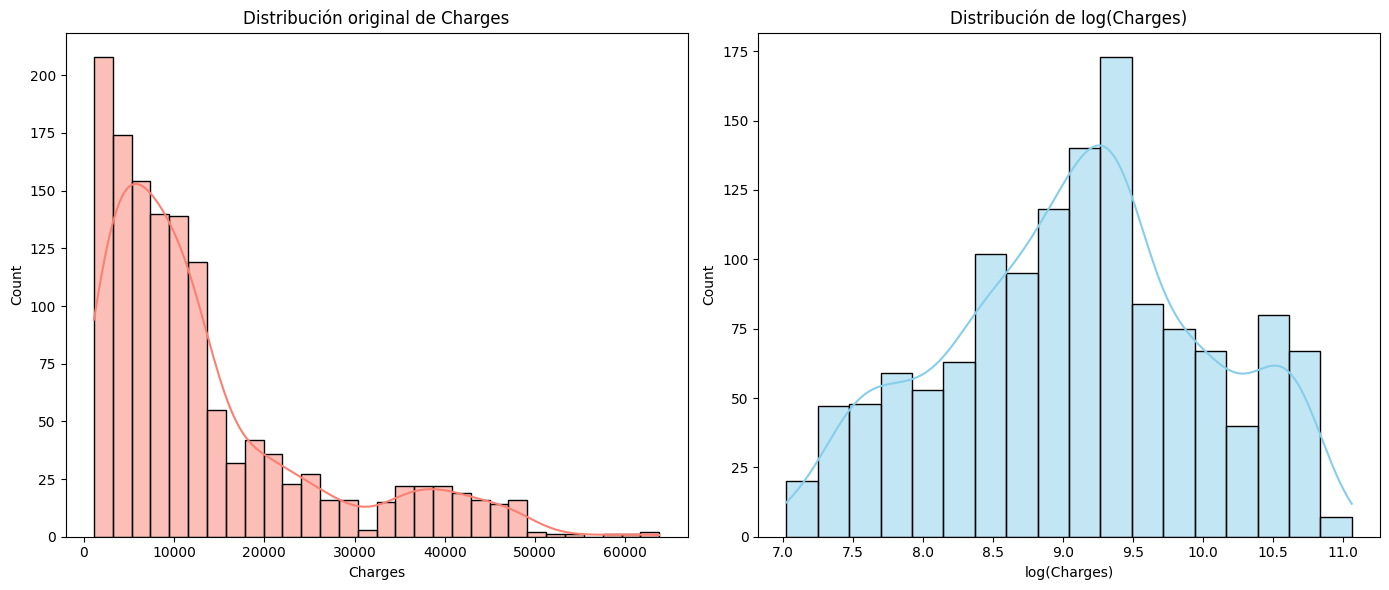

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Asegurar que NumPy está importado
import numpy as np

# Crear la nueva variable transformada
total_data["log_charges"] = np.log(total_data["charges"])

# Graficar comparaciones
plt.figure(figsize=(14, 6))

# Distribución original
plt.subplot(1, 2, 1)
sns.histplot(total_data["charges"], kde=True, color="salmon")
plt.title("Distribución original de Charges")
plt.xlabel("Charges")

# Distribución transformada
plt.subplot(1, 2, 2)
sns.histplot(total_data["log_charges"], kde=True, color="skyblue")
plt.title("Distribución de log(Charges)")
plt.xlabel("log(Charges)")

plt.tight_layout()
plt.show()


In [ ]:
from numpy._core.defchararray import upper
# TENEMOS QUE GUARDARNOS TODOS LOS DATASETS, ES DECIR:

total_data_CON_outliers = total_data.copy()
total_data_SIN_outliers = total_data.copy() # Lo vamos a modificar. Para cada variable con outliers, reemplazamos sus valores outliers

outliers_cols = ["age", "bmi", "children", "charges"]

def replace_outliers(column, df):
  col_stats = total_data[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(df[column])
  # Vamos a quitar los outliers superiores
  df[column] = df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
  # Vamos a quitar los outliers inferiores
  df[column] = df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in outliers_cols:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

outliers_dict # Este JSON me lo tengo que GUARDAR

{'age': [18, 87.0],
 'bmi': [13.7, 47.29],
 'children': [0, 5.0],
 'charges': [1121.8739, 34489.35]}

In [ ]:
with open("./outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

In [ ]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
total_data_CON_outliers["age"] = total_data["age"].fillna(total_data["age"].median()) # Cuando una variable es entera pero numérica/incontable
total_data_CON_outliers["bmi"] = total_data["bmi"].fillna(total_data["bmi"].median())
total_data_CON_outliers["children"]= total_data_CON_outliers["children"].fillna(total_data["children"].median())
total_data_CON_outliers.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
total_data_CON_outliers["smoker_num"] = total_data_CON_outliers["smoker"].map({"yes": 1, "no": 0})
total_data_SIN_outliers["smoker_num"] = total_data_SIN_outliers["smoker"].map({"yes": 1, "no": 0})

total_data_SIN_outliers.head()

,age,sex,bmi,children,smoker,region,charges,smoker_num
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [ ]:
total_data_CON_outliers["sex_num"] = total_data_CON_outliers["sex"].map({"female": 1, "male": 0})
total_data_SIN_outliers["sex_num"] = total_data_SIN_outliers["sex"].map({"female": 1, "male": 0})

total_data_SIN_outliers.head()

,age,sex,bmi,children,smoker,region,charges,smoker_num,Best_called,sex_num
0,19,female,27.900,0,yes,southwest,16884.92400,1,16903.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0,1743.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0,4477.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0,22017.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0,3898.85520,0


In [ ]:
total_data_CON_outliers["Best_called"] = total_data_CON_outliers["age"] + total_data_CON_outliers["charges"]
total_data_SIN_outliers["Best_called"] = total_data_SIN_outliers["age"] + total_data_SIN_outliers["charges"]

total_data_SIN_outliers.head()

,age,sex,bmi,children,smoker,region,charges,smoker_num,Best_called,sex_num
0,19,female,27.900,0,yes,southwest,16884.92400,1,16903.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0,1743.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0,4477.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0,22017.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0,3898.85520,0


In [ ]:
import sklearn
from sklearn.model_selection import train_test_split

# total_data_SIN_outliers
# total_data_CON_outliers

predictoras = ["age", "bmi", "charges", "children", "sex_num"]
target = ["smoker_num"]

X_CON = total_data_CON_outliers.drop(target, axis = 1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis = 1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 10)


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# X_train_CON_outliers
# X_train_SIN_outliers

# X_test_CON_outliers
# X_test_SIN_outliers

# TENGO QUE GUARDARME TRES SITUACIONES: 1) DATASET SIN TOCAR, 2) DATASET NORMALIZADO, 3) DATASET MIN-MAX

## NORMALIZACIÓN
### CON OUTLIERS
norm_CON_outliers = StandardScaler()
norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


## ESCALADO MIN-MAX (MINMAXIMIZACIÓN)
### CON OUTLIERS
scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)

# X_train_CON_outliers
# X_train_CON_outliers_norm
# X_train_CON_outliers_scal
# X_train_SIN_outliers
# X_train_SIN_outliers_norm
# X_train_SIN_outliers_scal

# X_test_CON_outliers
# X_test_CON_outliers_norm
# X_test_CON_outliers_scal
# X_test_SIN_outliers
# X_test_SIN_outliers_norm
# X_test_SIN_outliers_scal

In [87]:
X_train_CON_outliers.to_excel("../data/processed/X_train_CON_outliers.xlsx")
X_train_CON_outliers.to_excel("../data/processed/X_train_CON_outliers_norm.xlsx")
X_train_CON_outliers_scal.to_excel("../data/processed/X_train_CON_outliers_scal.xlsx")

X_train_SIN_outliers.to_excel("../data/processed/X_train_SIN_outliers.xlsx")
X_train_SIN_outliers_norm.to_excel("../data/processed/X_train_SIN_outliers_norm.xlsx")
X_train_SIN_outliers_scal.to_excel("../data/processed/X_train_SIN_outliers_scal.xlsx")

y_train.to_excel("../data/processed/y_train.xlsx")

In [88]:
import pandas as pd

X_train_CON_outliers = pd.read_excel("../data/processed/X_train_CON_outliers.xlsx")
X_train_CON_outliers_norm = pd.read_excel("../data/processed/X_train_CON_outliers_norm.xlsx")
X_train_CON_outliers_scal = pd.read_excel("../data/processed/X_train_CON_outliers_scal.xlsx")

X_train_SIN_outliers = pd.read_excel("../data/processed/X_train_SIN_outliers.xlsx")
X_train_SIN_outliers_norm = pd.read_excel("../data/processed/X_train_SIN_outliers_norm.xlsx")
X_train_SIN_outliers_scal = pd.read_excel("../data/processed/X_train_SIN_outliers_scal.xlsx")

y_train = pd.read_excel("../data/processed/y_train.xlsx")
